# 06: Lab - Data Scraping

## Objectives
1. Answer questions on M6
2. Web services: URLs, "REST", and APIs

## Set Up

In [1]:
# Import typical packages
import requests
import pandas as pd
import seaborn as sns

In [2]:
# `io` package -- to work with streams of data 
import io

In [7]:
#The USGS dataretrieval package; install if necessary
try:
    import dataretrieval as dr
except ImportError:
    %pip install dataretrieval --no-deps 
    import dataretrieval as dr

In [8]:
#The tidycensus package; install if necessary
try:
    import pytidycensus as tc
except ImportError:
    %pip install pytidycensus 
    import pytidycensus as tc

In [5]:
#Set the seaborn theme
sns.set_theme(style='darkgrid',context='notebook')

## Web Services - An Introduction

### ✅An Exercise
* Open your browser to Google's home page
* Search for "Duke University"
* Check the URL of the search result
 - Within the url is `q=Duke+University`
* Try the URL: "https://www.google.com/search?q=NSOE"

### 🤔An Explainer
* Interacting with the web boils down to **requests** and **responses**

* Requests are often sent as browser URLs. They usually include:
    - The address of the server that will handle the request
    - The name of the service on that server that will process the request
    - The parameters of the service<br> 🗣️ ***Can you identify these components in the Google search request?***
 
* Responses are sent as text files, which are interpreted by a browser
    - Written in HTML: Tags (w/attributes) & Values, which browsers can interpret
    - Often include JavaScript, which browsers can run
 
* "REST" is the framework of sending requests and handling responses - all in text.
    - "REpresentational State Transfer"
    - REST is a form of an API..


### Why do we care? 🔥*Because we can use this to find & fetch data!🔥*
#### ✅Another example...
1. Navigate to: <https://waterdata.usgs.gov/>
1. Select **Go to the National Water Dashboard**
    - <https://dashboard.waterdata.usgs.gov/app/nwd/en/>
1. Search for the site number `02087500` and select the result "Neuse River Near Clayton, NC"
1. Click on the point, a hydrograph will open
    - <https://dashboard.waterdata.usgs.gov/api/gwis/2.1.1/service/site?agencyCode=USGS&siteNumber=02087500&open=89192>
1. Click on the `site page` link
    - <https://waterdata.usgs.gov/monitoring-location/USGS-02087500>
1. Open the browser's "Developer's Tools Interface" (`<ctrl>-<shift>-<i>`)
    - Activate the "Network" tab
    - Reload the page
    - Filter for "Fetch/XHR"
    - Sort on size
    - Browse for URLs that look like requests
    - Find and test some URLS:  
> <https://api.waterdata.usgs.gov/ogcapi/v0/collections/field-measurements/items?limit=10000&skipGeometry=true&properties=parameter_code,value,unit_of_measure,time,qualifier,approval_status&monitoring_location_id=USGS-02087500>
  
#### 👉*Examine the API documentation*: 
<https://api.waterdata.usgs.gov/ogcapi/v0/openapi?f=html#/continuous>
* Replace `monitoring_location_id` with `USGS-02087500`
* Add "`%f=csv`" to end

In [9]:
base_url = 'https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous/items?'
params = {
    'limit':50000,
    'time':'P7D',
    'skipGeometry':'false',
    'properties':'parameter_code,value,unit_of_measure,time,approval_status',
    'monitoring_location_id':'USGS-02087500',
    'parameter_code':'00060,00061,00062,00063,00064,00065',
    'f':'csv'
}
response = requests.get(base_url,params=params)

In [10]:
#Convert to a dataframe
df_usgs = pd.read_csv(
    io.StringIO(response.text),
    dtype={'parmeter_code':'category'},
    parse_dates=['time'])
#Examine
df_usgs.head()

,x,y,parameter_code,value,unit_of_measure,time,approval_status
0,-78.405278,35.647222,65,1.31,ft,2026-09-24 19:45:00+00:00,Provisional
1,-78.405278,35.647222,65,1.30,ft,2026-09-24 20:00:00+00:00,Provisional
2,-78.405278,35.647222,65,1.31,ft,2026-09-24 20:15:00+00:00,Provisional
3,-78.405278,35.647222,65,1.31,ft,2026-09-24 20:30:00+00:00,Provisional
4,-78.405278,35.647222,65,1.30,ft,2026-09-24 20:45:00+00:00,Provisional


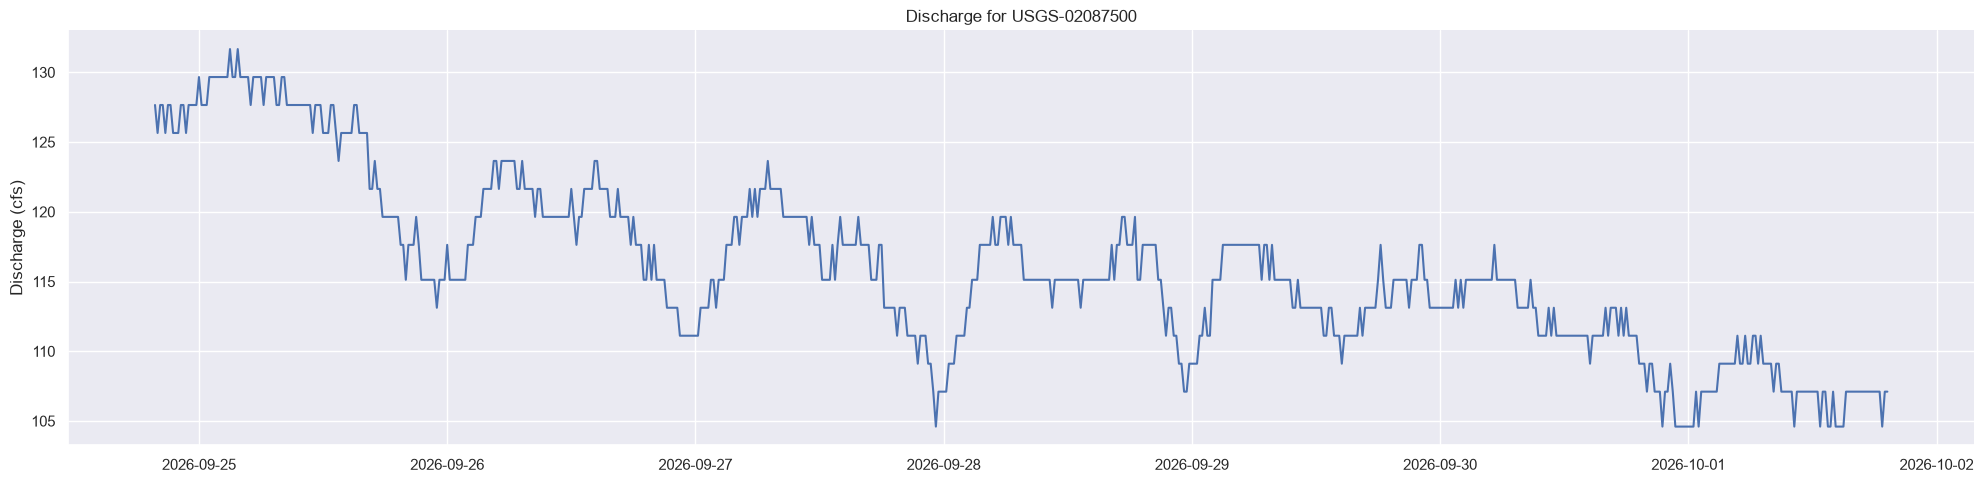

In [11]:
#Plot
sns.relplot(
    data = df_usgs,
    x='time', 
    y='value',
    kind='line',
    errorbar=None,
    aspect=4
).set(
    title=f'Discharge for {params['monitoring_location_id']}',
    ylabel='Discharge (cfs)',
    xlabel=''
    );


### Exercise: 
> The above code chunk is copied below. Edit it so that it plots the last *24* days of flow for gage *02085070*

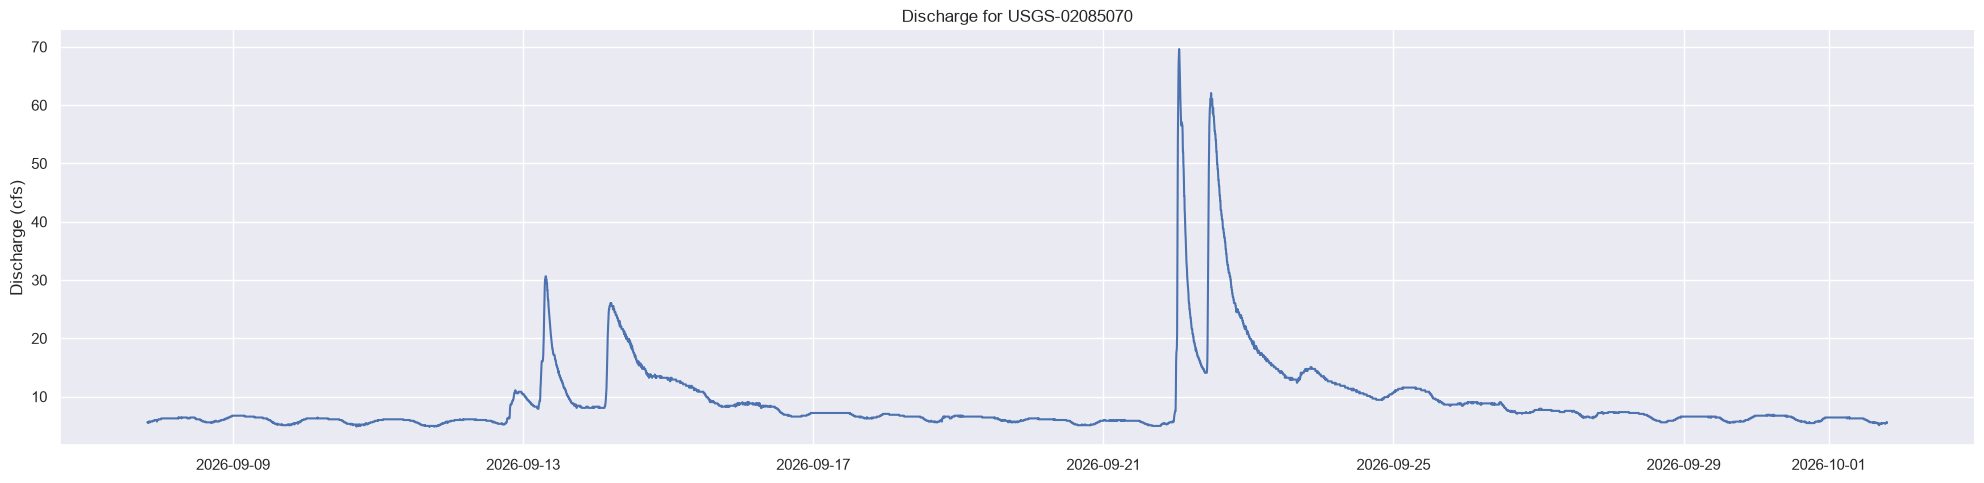

In [13]:
base_url = 'https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous/items?'
params = {
    'limit':50000,
    'time':'P24D',
    'skipGeometry':'false',
    'properties':'parameter_code,value,unit_of_measure,time,approval_status',
    'monitoring_location_id':'USGS-02085070',
    'parameter_code':'00060,00061,00062,00063,00064,00065',
    'f':'csv'
}
response = requests.get(base_url,params=params)

#Convert to a dataframe
df_usgs = pd.read_csv(
    io.StringIO(response.text),
    dtype={'parmeter_code':'category'},
    parse_dates=['time'])

#Plot
sns.relplot(
    data = df_usgs,
    x='time', 
    y='value',
    kind='line',
    errorbar=None,
    aspect=4
).set(
    title=f'Discharge for {params['monitoring_location_id']}',
    ylabel='Discharge (cfs)',
    xlabel=''
    );

## APIs

Application programming interfaces, or APIs, are a formalization of the REST request/response process. More precisely, they are web sites that have been designed to allow a client to query specific bits of data from an on-line resource without just "hacking" a URL.

More and more organizations are providing API access to their data. Have a look at the US Census catalog of APIs to grab demographic data: <https://www.census.gov/data/developers/data-sets.html>.

And with the formalization of APIs, more R packages are being written to streamline access to data via these APIs. Let's look at some examples. 


### Grabbing discharge data via  the `dataRetrieval` package
More info: <https://doi-usgs.github.io/dataretrieval-python//>

In [ ]:
#Identify sites to download
site_number = 'USGS-02087500'
site_numbers = ['USGS-02087500','USGS-02085070']

#Identify parameter of interest: 
pcode = '00060' #discharge (cfs)

#Load in the data using the package's "read_waterdata_continuous" function
neuse, _ = dr.waterdata.get_continuous(
  monitoring_location_id = site_numbers,
  parameter_code = pcode,
  time = 'P7D',
)

#Convert the time column to datetime datatype
neuse['time'] = pd.to_datetime(neuse['time'])

#Plot
sns.relplot(
    data=neuse,
    x='time',
    y='value',
    hue='monitoring_location_id',
    kind='line',
    errorbar=None,
    aspect=4
);

### Using `pytidycensus` to extract census data
The `pytidycensus` package uses the Census' API to pull data into our coding environment. To use it, however, you first need to get a free Census API key at <https://api.census.gov/data/key_signup.html>. After that, it's pretty easy to fetch data into your coding environment. 

We'll use it to extract total population of counties in NC. 

You'll also need to look up the IDs of the variables you want to extract. Those are found here:
<https://walker-data.com/tidycensus/articles/basic-usage.html#searching-for-variables>

More info: <https://mmann1123.github.io/pytidycensus/>

In [14]:
# R workflow to translate with requests/BeautifulSoup/pandas/Seaborn:
# #Apply the API key
## census wants us to have a key to access the data, hence, API key, lets census track who it is and can turn it off
tc.set_census_api_key("d4ad7874c996c7a83fec0a81466309ddc07d8e22")
# 
nc_pop = tc.get_acs(
    geography = "county",
    variables = "B01003_001",
    state = "NC",
    geometry = True)

Census API key has been set for this session.
Getting data from the 2018-2022 5-year ACS


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

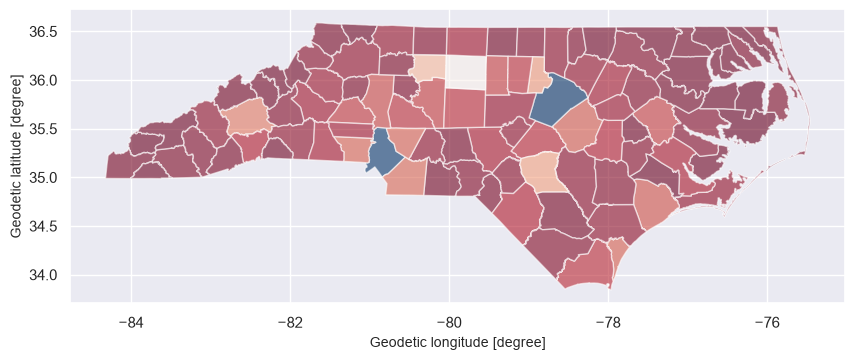

In [15]:
#Plot
nc_pop.plot(
    column='B01003_001E',
    figsize=(10,5),
    cmap='RdBu',
    alpha=0.6)